<a href="https://colab.research.google.com/github/solomon7-data/Employee-/blob/main/Phase_2_Missing_value_analysis_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [119]:
df=pd.read_csv('https://github.com/solomon7-data/Employee-/raw/main/cleaned_athlete_data.csv.zip',compression='zip')
df.drop(columns=['died'],inplace=True)
df = df.sort_values('born_date')
df.head(2)

,roles,sex,full_name,height_cm,weight_kg,born_date,date_died,age_at_death,city,region,country
62451,Competed in Olympic Games,Male,Charles William•Martin,NaN,NaN,1828-10-25,1905-02-25,77.0,Rouen,Seine-Maritime,FRA
63109,Competed in Olympic Games,Male,Ferdinand Philippe•de Schlatter,NaN,NaN,1831-02-14,1907-07-04,77.0,Paris IVe,Paris,FRA


In [120]:
# check data type and make a change
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145500 entries, 62451 to 144132
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   roles         145500 non-null  object 
 1   sex           145500 non-null  object 
 2   full_name     145500 non-null  object 
 3   height_cm     106651 non-null  float64
 4   weight_kg     104210 non-null  float64
 5   born_date     143698 non-null  object 
 6   date_died     33963 non-null   object 
 7   age_at_death  33872 non-null   float64
 8   city          119398 non-null  object 
 9   region        119398 non-null  object 
 10  country       119398 non-null  object 
dtypes: float64(3), object(8)
memory usage: 13.3+ MB


In [121]:
# change born_date and date_died data type to date time
df['born_date'] = pd.to_datetime(df['born_date'],errors='coerce')
df['date_died'] = pd.to_datetime(df['date_died'],errors='coerce')

In [122]:
# check for missing values in percent
(df.isna().sum()/len(df)*100).round()

,0
roles,0.0
sex,0.0
full_name,0.0
height_cm,27.0
weight_kg,28.0
born_date,1.0
date_died,77.0
age_at_death,77.0
city,18.0
region,18.0


In [123]:
# here lets see if the missing values have at random or not by Select only numerical columns for the MCAR test
numeric_df = df.select_dtypes(include=np.number)

mcar = MCARTest(method="little")
p_value = mcar.little_mcar_test(numeric_df)

print("p-value:", p_value)
#  as we can see the p-value is 0 which indicates the missing values are not at random lets explore more the relation ship of missing value

p-value: 0.0


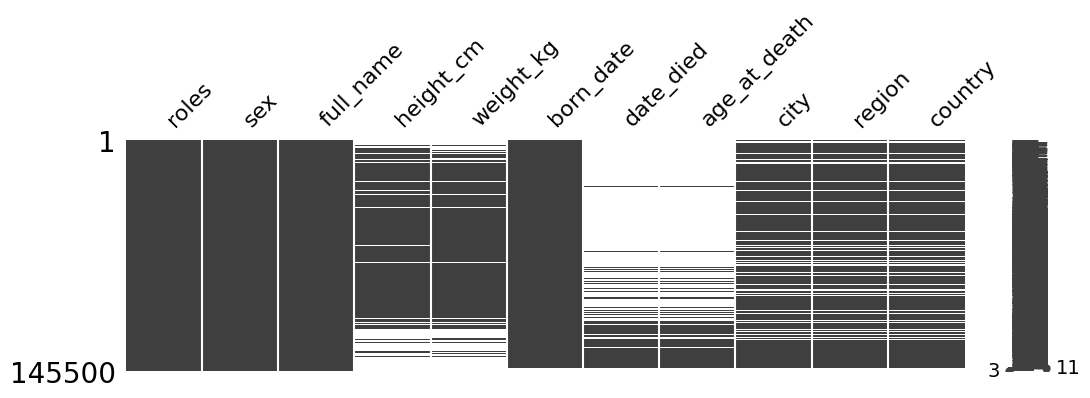

In [127]:
# let run the matrix if there is any pattern across records or between columns or dates
df = df.sort_values('born_date',ascending=False)
msno.matrix(df, figsize=(12,3))
plt.show()


on the above matrix there seems relationship columns of missing value  value specially between 'height' and 'wieght', 'date_died' and 'age_at_death',

<Axes: >

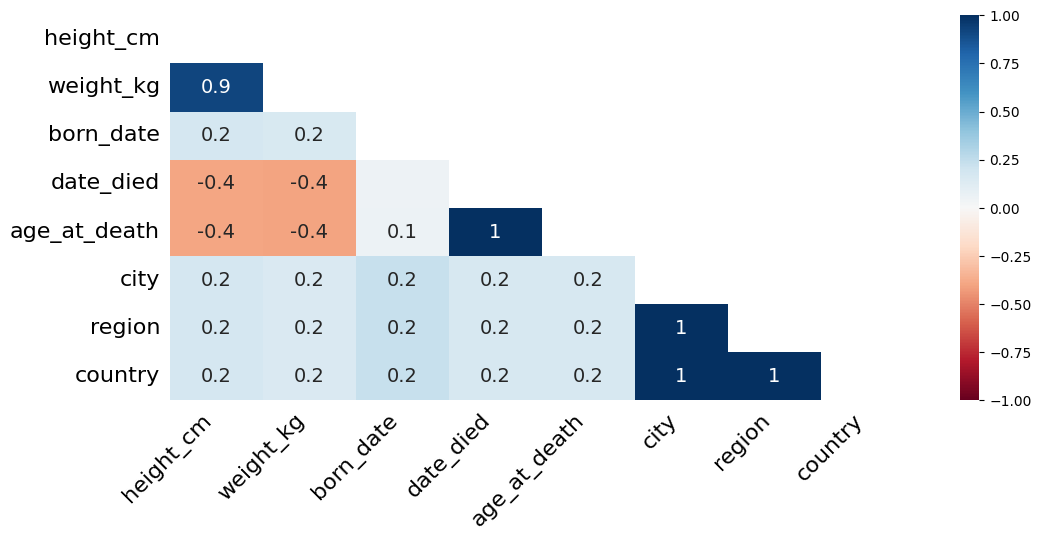

In [125]:
# here we are trying to see which columns have strong ralation ship for mmissing value
# +1: the missing values correlate the variables tend to be missing together.
# 0: No relationship.
# −1: When one is missing, the other is almost always present.
msno.heatmap(df,figsize=(12,5))

In [132]:
df[df['age_at_death'] == df['age_at_death'].min()]

,roles,sex,full_name,height_cm,weight_kg,born_date,date_died,age_at_death,city,region,country
143251,Competed in Olympic Games,Female,Eya•Guezguez,NaN,NaN,2005-03-12,2022-04-10,17.0,M'saken,Susa,TUN
95351,Competed in Olympic Games,Female,"Laurence Rochon ""Laurie""•Owen",NaN,NaN,1944-05-09,1961-02-15,17.0,Berkeley,California,USA



**root cause analysis for missing value.**

based on the above heat map we can identify columns which are highly correlated for theire missing value

1.   city,region and country have 100 percent correlation this happens  because those three columns are splited from one column in our phase one data cleaning proccess
2.  the other is height_cm and weight_kg have 90% correlation for their missing value which is also attributable to that they are extracted from one column called 'attribute' during our data cleaning process.
3. but the relation ship between date_died and age_at death is natural because we cant have age_at_death for a person who is alive.
3. and we found two athelets died at younger age (17 yrs old) and from wikipedia source the one from tunis died of drowning and the one form us died from plane crash
